In [1]:
import findspark
findspark.init()
findspark.find()

'c:\\Users\\jfmag\\anaconda3\\envs\\BigData\\Lib\\site-packages\\pyspark'

In [2]:
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession

spk = SparkSession.builder.master("local[*]").getOrCreate()
spk.conf.set("spark.sql.repl.eagerEval.enabled", True)
spk

In [3]:
df= spk.read.csv('C:/Users/jfmag/OneDrive/Documentos/Maestría/Big Data/KG_DATA/loan.csv', header=True, inferSchema=True)
df.show()

+----+---------+---------+-----------+---------------+----------+--------+-----------+-----+---------+--------------------+----------+--------------+----------+-------------------+--------+-----------+----------+----+----+------------------+--------------------+--------+----------+-----+-----------+----------------+--------------+----------------------+----------------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+-----------+---------------+---------------+-------------+------------------+----------+-----------------------+------------+---------------+------------+------------------+--------------------------+---------------------------+-----------+----------------+----------------+---------+-------------------------+--------------+------------+-----------+-----------+-----------+-----------+-----------+------------------+------------+-------+-----------+-----------+----------+--------+----------------+------+-----------+------------

In [4]:
columnas = [
    'out_prncp',#Remaining outstanding principal for total amount funded
    'open_acc',#The number of open credit lines in the borrower's credit file.
    'num_sats',#Number of satisfactory accounts
    'total_rec_prncp',#Principal received to date
    'num_rev_tl_bal_gt_0',#Number of revolving trades with balance >0
    'num_actv_rev_tl',#Number of currently active revolving trades
    'tot_hi_cred_lim',#Total high credit/credit limit
    'tot_cur_bal', #Total current balance of all accounts
    'last_pymnt_amnt',#Last total payment amount received
    'total_bal_il',#Total current balance of all installment accounts
    'total_il_high_credit_limit',#Total installment high credit/credit limit
    'installment',#The monthly payment owed by the borrower if the loan originates.
    'total_bal_ex_mort',#Total credit balance excluding mortgage
    'revol_util',#Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
    'bc_util', #Ratio of total current balance to high credit/credit limit for all bankcard accounts.
    'emp_length',
    'home_ownership',
    'grade',#Variable de salida no supervisadso
    'funded_amnt'#The total amount committed to that loan at that point in time. #VARIABLE DE SALIDA SUPERVISADO
]

dfML = df.select(columnas)

In [5]:
from pyspark.sql.functions import regexp_replace, col
#sintaxis casteo
#   'cast (loan_amnt as double) loan_amnt',

columns_cast = [
'cast (out_prncp as double) out_prncp',
'cast (num_sats as int) num_sats',
'cast (total_rec_prncp as double) total_rec_prncp',
'cast (num_rev_tl_bal_gt_0 as int) num_rev_tl_bal_gt_0',
'cast (num_actv_rev_tl as int) num_actv_rev_tl',
'cast (tot_hi_cred_lim as double)  tot_hi_cred_lim',
'cast (tot_cur_bal as double)tot_cur_bal',
'cast (open_acc as int) open_acc',
'cast (last_pymnt_amnt as double) last_pymnt_amnt',
'cast (total_bal_il as double) total_bal_il',
'cast (total_il_high_credit_limit as double) total_il_high_credit_limit',
'cast (installment as double) installment',
'cast (total_bal_ex_mort as double) total_bal_ex_mort',
'cast (revol_util as double) revol_util',
'cast (bc_util as double) bc_util',
'cast (emp_length as string) emp_length',
'cast (home_ownership as string) home_ownership',
'cast (grade as string) grade',
'cast (funded_amnt as int) funded_amnt'
]

# Aplicamos la conversión sobre todo el DataFrame
dfML = dfML.selectExpr(*columns_cast)

# Mostrar el resultado
dfML.dtypes

[('out_prncp', 'double'),
 ('num_sats', 'int'),
 ('total_rec_prncp', 'double'),
 ('num_rev_tl_bal_gt_0', 'int'),
 ('num_actv_rev_tl', 'int'),
 ('tot_hi_cred_lim', 'double'),
 ('tot_cur_bal', 'double'),
 ('open_acc', 'int'),
 ('last_pymnt_amnt', 'double'),
 ('total_bal_il', 'double'),
 ('total_il_high_credit_limit', 'double'),
 ('installment', 'double'),
 ('total_bal_ex_mort', 'double'),
 ('revol_util', 'double'),
 ('bc_util', 'double'),
 ('emp_length', 'string'),
 ('home_ownership', 'string'),
 ('grade', 'string'),
 ('funded_amnt', 'int')]

1 Construcción de la muestra M

In [6]:
# Se añade una nueva columna que combina los valores de los atributos grade, home_ownership y emp_length
from pyspark.sql.functions import concat, lit
dfML = dfML.withColumn(
    "stratum", 
    concat(
        dfML["grade"], lit("_"), dfML["home_ownership"], lit("_"), dfML["emp_length"]
    )
)
dfML.show(5)

+---------+--------+---------------+-------------------+---------------+---------------+-----------+--------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+----------+--------------+-----+-----------+--------------------+
|out_prncp|num_sats|total_rec_prncp|num_rev_tl_bal_gt_0|num_actv_rev_tl|tot_hi_cred_lim|tot_cur_bal|open_acc|last_pymnt_amnt|total_bal_il|total_il_high_credit_limit|installment|total_bal_ex_mort|revol_util|bc_util|emp_length|home_ownership|grade|funded_amnt|             stratum|
+---------+--------+---------------+-------------------+---------------+---------------+-----------+--------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+----------+--------------+-----+-----------+--------------------+
|  2386.02|       9|         113.98|                  5|              5|        60124.0|    16901.0|       9|          84.92|     12560.0|                   181

In [7]:
rows_stratum=dfML.groupBy('stratum').count().collect()
print("Número de estratos:", len(rows_stratum))
print(rows_stratum)

Número de estratos: 413
[Row(stratum='F_MORTGAGE_9 years', count=788), Row(stratum='A_MORTGAGE_n/a', count=14226), Row(stratum='A_RENT_9 years', count=4292), Row(stratum='D_OWN_4 years', count=2095), Row(stratum='A_ANY_5 years', count=12), Row(stratum='B_RENT_4 years', count=17994), Row(stratum='B_OWN_4 years', count=3939), Row(stratum='C_MORTGAGE_10+ years', count=123865), Row(stratum='D_RENT_8 years', count=5417), Row(stratum='B_OWN_7 years', count=2727), Row(stratum='F_RENT_8 years', count=801), Row(stratum='A_ANY_9 years', count=12), Row(stratum='C_MORTGAGE_4 years', count=16425), Row(stratum='D_MORTGAGE_1 year', count=7290), Row(stratum='B_OWN_1 year', count=4070), Row(stratum='A_ANY_< 1 year', count=30), Row(stratum='F_OWN_9 years', count=165), Row(stratum='F_OWN_< 1 year', count=329), Row(stratum='D_RENT_n/a', count=8842), Row(stratum='D_ANY_5 years', count=14), Row(stratum='G_MORTGAGE_< 1 year', count=354), Row(stratum='D_MORTGAGE_6 years', count=6688), Row(stratum='G_OWN_10+ y

In [8]:
from pyspark.sql.functions import rand

# Agregar una columna aleatoria para desordenar los registros
dfML_randomized = dfML.withColumn("random_col", rand()).orderBy("stratum", "random_col")

# Crear el diccionario de fracciones para cada estrato
fractions_dict = {row["stratum"]: 0.3 for row in rows_stratum}  # Se tomará el 30% de cada estrato

# Aplicar muestreo estratificado después de revolver los registros
df_muestra = dfML_randomized.sampleBy("stratum", fractions=fractions_dict, seed=42)

# Mostrar los resultados
print(f"Existen {df_muestra.count()} instancias en la muestra.")
df_muestra.show(5)

Existen 678733 instancias en la muestra.
+---------+--------+---------------+-------------------+---------------+---------------+-----------+--------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+----------+--------------+-----+-----------+---------------+-------------------+
|out_prncp|num_sats|total_rec_prncp|num_rev_tl_bal_gt_0|num_actv_rev_tl|tot_hi_cred_lim|tot_cur_bal|open_acc|last_pymnt_amnt|total_bal_il|total_il_high_credit_limit|installment|total_bal_ex_mort|revol_util|bc_util|emp_length|home_ownership|grade|funded_amnt|        stratum|         random_col|
+---------+--------+---------------+-------------------+---------------+---------------+-----------+--------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+----------+--------------+-----+-----------+---------------+-------------------+
|   2981.3|      10|         6018.7|                  5|              5|  

In [9]:
rows_stratum=df_muestra.groupBy('stratum').count().collect()
print("Número de estratos:", len(rows_stratum))
print(rows_stratum)

Número de estratos: 359
[Row(stratum='A_MORTGAGE_n/a', count=4236), Row(stratum='A_ANY_5 years', count=4), Row(stratum='A_ANY_9 years', count=4), Row(stratum='A_ANY_< 1 year', count=9), Row(stratum='A_MORTGAGE_6 years', count=3346), Row(stratum='A_MORTGAGE_2 years', count=5312), Row(stratum='A_MORTGAGE_9 years', count=2702), Row(stratum='A_OWN_7 years', count=522), Row(stratum='A_MORTGAGE_< 1 year', count=4962), Row(stratum='A_OWN_5 years', count=821), Row(stratum='A_ANY_6 years', count=2), Row(stratum='A_NONE_< 1 year', count=2), Row(stratum='A_OWN_9 years', count=491), Row(stratum='A_OTHER_10+ years', count=2), Row(stratum='A_MORTGAGE_4 years', count=3959), Row(stratum='A_OWN_3 years', count=924), Row(stratum='A_MORTGAGE_5 years', count=4328), Row(stratum='A_OWN_6 years', count=526), Row(stratum='A_NONE_2 years', count=1), Row(stratum='A_MORTGAGE_7 years', count=2879), Row(stratum='A_ANY_10+ years', count=12), Row(stratum='A_ANY_4 years', count=5), Row(stratum='A_ANY_2 years', count=

2 Construcción Train – Test

In [10]:
# Construcción de un train - test con 1 ejecutor
spk.conf.set("spark.sql.shuffle.partitions", "1")
train_data,test_data = df_muestra.randomSplit([0.7,0.3], seed = 42)
print(f"""Existen {train_data.count()} instancias en el conjunto train, y {test_data.count()} en el conjunto test""")

Existen 475459 instancias en el conjunto train, y 203749 en el conjunto test


3 Selección de métricas para medir calidad de resultados

Para los modelos supervisados se tomarán las métricas de R2, MAE y RMSE. Esto debido a que R2 indica que tan juntos están los puntos de la recta de la regresión lineal. El MAE, entiendo son las barras de error, es decir, el punto proyectaado, qué tan lejano está del valor real o de la linea de regresión. Por úlitmo, el RSME indica el promedio de las desviaciones del valor real y penaliza los outliers.

Para mi poryecto, resulta de gran importancia el RMSE debido a que tengo demasiados outliers.

En el caso del aprendizaje supervisado, se utilizarán la curva ROC y PR. La ROC grafica dos métricas, la TPR (true positive rate - eje Y) contra la FPR (false positive rate - eje x). Esto nos indica que tan acertivo el el modelo al momento de pronosticar. Mientras que la curva PR indica que tan preciso es el modelo al momento de realizar la predicción. Es decir, la ROC nos muestra que tan bien predice, mientras que la PR indica el nivel de error del modelo.

4 Entrenamiento de Modelos de Aprendizaje

In [11]:
#1. EDA sobre train_data para validar que sigo teniendo los mismos patrones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df_TD= train_data.toPandas()

num_cols = df_TD.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_TD.select_dtypes(exclude=np.number).columns.tolist()

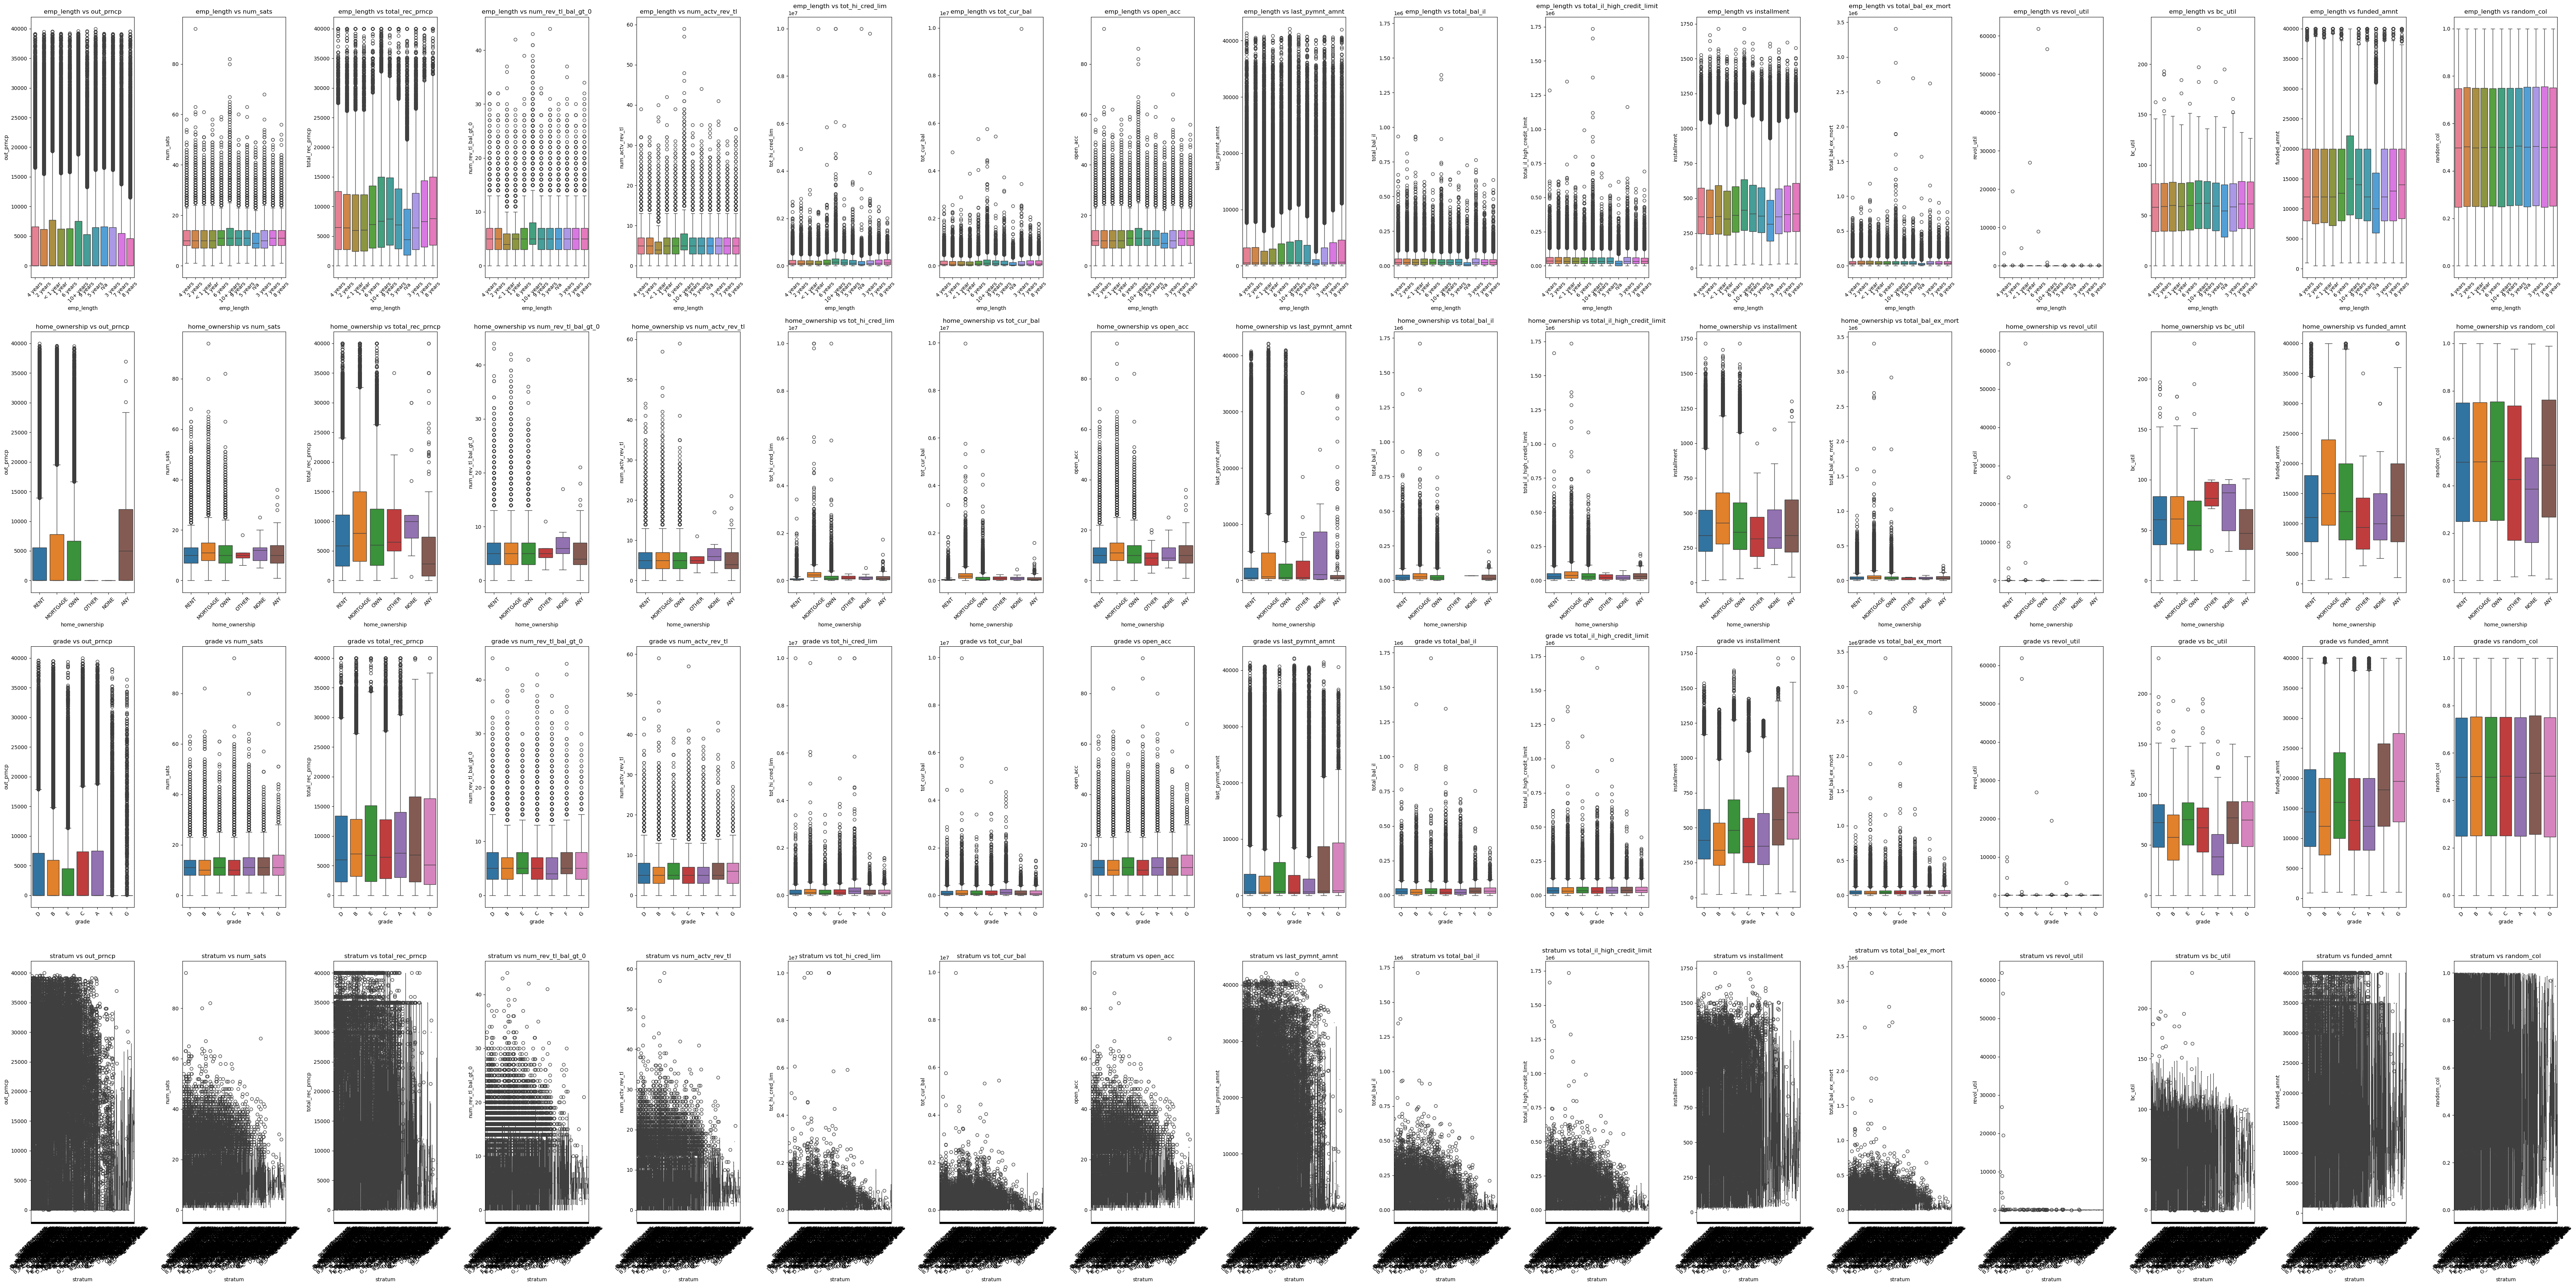

In [13]:
fig, axes = plt.subplots(len(cat_cols), len(num_cols), figsize=(70,35))

for i, col in enumerate(cat_cols):
    for j, col2 in enumerate(num_cols):
        sns.boxplot(x=col, y=col2, data=df_TD, ax=axes[i][j], hue=col)
        axes[i][j].set_title(f'{col} vs {col2}')
        axes[i][j].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
from pyspark.sql.functions import median, when, col

def imputar_medianas(df):
    """
    Imputa valores nulos en un DataFrame usando la mediana por grupo.
    
    Args:
    df (DataFrame): DataFrame de entrada.
    columnas_excluir (list): Lista de columnas que no se incluirán en la imputación.
    
    Returns:
    DataFrame: DataFrame con valores nulos imputados.
    """
    # Definir columnas a incluir en la imputación
    columns_to_include = [col for col in df.columns if col not in ['home_ownership', 'emp_length', 'grade', 'funded_amt', 'installment', 'stratum']]

    # Calcular las medianas agrupadas por 'home_ownership', 'emp_length' y 'grade'
    df_median = df.groupBy("stratum").agg(
        *[median(col).alias(f"median_{col}") for col in columns_to_include]
    )

    # Hacer join para agregar las medianas correctas a cada registro
    df_imputed = df.join(df_median, on=["stratum"], how="left")

    # Imputar valores nulos con la mediana correspondiente
    for column in columns_to_include:
        df_imputed = df_imputed.withColumn(
            column,
            when(col(column).isNull(), col(f"median_{column}")).otherwise(col(column))
        )

    return df_imputed

In [15]:
#3.1 se imputan medianas en el df
train_data_med=imputar_medianas(train_data)
train_data_med.show(3)
train_data_med = train_data_med.na.drop()

+------------------+---------+--------+---------------+-------------------+---------------+---------------+-----------+--------+---------------+------------+--------------------------+-----------+-----------------+------------------+-------+----------+--------------+-----+-----------+------------------+----------------+---------------+----------------------+--------------------------+----------------------+----------------------+------------------+---------------+----------------------+-------------------+---------------------------------+------------------------+------------------+--------------+------------------+------------------+
|           stratum|out_prncp|num_sats|total_rec_prncp|num_rev_tl_bal_gt_0|num_actv_rev_tl|tot_hi_cred_lim|tot_cur_bal|open_acc|last_pymnt_amnt|total_bal_il|total_il_high_credit_limit|installment|total_bal_ex_mort|        revol_util|bc_util|emp_length|home_ownership|grade|funded_amnt|        random_col|median_out_prncp|median_num_sats|median_total_rec_prn

In [16]:
#3.2 se hacen los encoders,los vectores y se escalan las variables numéricas on robust scaler
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import RobustScaler, VectorAssembler
from pyspark.ml import Pipeline

en_idx = StringIndexer(inputCol="stratum", outputCol="stratum_index")

en_ohe = OneHotEncoder(inputCol="stratum_index", outputCol="stratum_OHE")

asmblr_lr = VectorAssembler(
    inputCols=[
       'out_prncp',
        'num_sats',
        'total_rec_prncp',
        'num_rev_tl_bal_gt_0',
        'num_actv_rev_tl',
        'tot_hi_cred_lim',
        'tot_cur_bal',
        'open_acc',
        'last_pymnt_amnt',
        'total_bal_il',
        'total_il_high_credit_limit',
        'installment',
        'total_bal_ex_mort',
        'revol_util',
        'bc_util'
    ],
    outputCol="vct_cols"
)


robust = RobustScaler(inputCol="vct_cols", outputCol="scaled_features")

# creo el pipeline
pipeline_lr = Pipeline(stages=[en_idx, en_ohe, asmblr_lr, robust])

# ejecución del pipeline
pipeline_model_lr = pipeline_lr.fit(train_data_med)
df_train_lr = pipeline_model_lr.transform(train_data_med)



In [17]:
assembler_Knn= VectorAssembler (
  inputCols=[
    'out_prncp',
    'num_sats',
    'total_rec_prncp',
    'num_rev_tl_bal_gt_0',
    'num_actv_rev_tl',
    'tot_hi_cred_lim',
    'tot_cur_bal',
    'open_acc',
    'last_pymnt_amnt',
    'total_bal_il',
    'total_il_high_credit_limit',
    'installment',
    'revol_util',
    'total_bal_ex_mort',
    'bc_util',
    'funded_amnt'
  ],
  outputCol="features"
)

robust = RobustScaler(inputCol="features", outputCol="scaled_features")

# creo el pipeline
pipeline_knn = Pipeline(stages=[en_idx, en_ohe, assembler_Knn, robust])

# ejecución del pipeline
pipeline_model_knn = pipeline_knn.fit(train_data_med)
df_train_knn = pipeline_model_knn.transform(train_data_med)

In [18]:
#3.3 regresión lineal
from pyspark.ml.regression import LinearRegression

fa_lr= LinearRegression(featuresCol='scaled_features', labelCol='funded_amnt')
fa_lr_model= fa_lr.fit(df_train_lr)
metrics_lr=fa_lr_model.evaluate(df_train_lr)
print('RMSE: ', metrics_lr.rootMeanSquaredError)
print('R2: ', metrics_lr.r2)

print('MAE: ', metrics_lr.meanAbsoluteError)


RMSE:  2455.2643441378627
R2:  0.9287651075946666
MAE:  1771.4480870656078


In [19]:
print (fa_lr_model.explainParams())

aggregationDepth: suggested depth for treeAggregate (>= 2). (default: 2)
elasticNetParam: the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty. (default: 0.0)
epsilon: The shape parameter to control the amount of robustness. Must be > 1.0. Only valid when loss is huber (default: 1.35)
featuresCol: features column name. (default: features, current: scaled_features)
fitIntercept: whether to fit an intercept term. (default: True)
labelCol: label column name. (default: label, current: funded_amnt)
loss: The loss function to be optimized. Supported options: squaredError, huber. (default: squaredError)
maxBlockSizeInMB: maximum memory in MB for stacking input data into blocks. Data is stacked within partitions. If more than remaining data size in a partition then it is adjusted to the data size. Default 0.0 represents choosing optimal value, depends on specific algorithm. Must be >= 0. (default: 0.0)
maxIter: max nu

In [20]:
#3.3.1 hiperparámetros y grid search

from pyspark.ml.tuning import ParamGridBuilder

params_lr = ParamGridBuilder() \
    .addGrid(fa_lr.aggregationDepth,[5,15,20]) \
    .addGrid(fa_lr.elasticNetParam,[1]) \
    .addGrid(fa_lr.epsilon,[40000]) \
    .addGrid(fa_lr.featuresCol,['scaled_features']) \
    .addGrid(fa_lr.fitIntercept,[True, False]) \
    .addGrid(fa_lr.labelCol,['funded_amnt']) \
    .addGrid(fa_lr.loss,['squaredError']) \
    .addGrid(fa_lr.maxIter,[100,150,200]) \
    .addGrid(fa_lr.predictionCol,['pred_funded_amt']) \
    .addGrid(fa_lr.regParam,[250,300,500]) \
    .addGrid(fa_lr.solver,['auto']) \
    .addGrid(fa_lr.standardization,[False]) \
    .addGrid(fa_lr.tol,[0.7,0.5,0.25]) \
    .build()

In [21]:
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator


# Definir evaluador con métrica RMSE
evaluator = RegressionEvaluator(labelCol="funded_amnt", predictionCol="pred_funded_amt", metricName="rmse")

# CrossValidator para GridSearch con validación cruzada
crossval = CrossValidator(
    estimator=fa_lr,
    estimatorParamMaps=params_lr,  #Aquí pasamos el Grid de hiperparámetros
    evaluator=evaluator,
    numFolds=3  #Número de folds para validación cruzada, aqui e donde pueden ir 100 o más
)

#fit del modelo
cv_model = crossval.fit(df_train_lr)

#Evaluar el mejor modelo encontrado
metrics_lr = cv_model.bestModel.summary
print('RMSE:', metrics_lr.rootMeanSquaredError)
print('R2:', metrics_lr.r2)
print('MAE:', metrics_lr.meanAbsoluteError)

RMSE: 2482.767056254551
R2: 0.9801687609795564
MAE: 1742.579649420126


In [22]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

kmeans = KMeans(featuresCol='features',k=7, seed=42)

In [23]:
print (kmeans.explainParams())

distanceMeasure: the distance measure. Supported options: 'euclidean' and 'cosine'. (default: euclidean)
featuresCol: features column name. (default: features, current: features)
initMode: The initialization algorithm. This can be either "random" to choose random points as initial cluster centers, or "k-means||" to use a parallel variant of k-means++ (default: k-means||)
initSteps: The number of steps for k-means|| initialization mode. Must be > 0. (default: 2)
k: The number of clusters to create. Must be > 1. (default: 2, current: 7)
maxBlockSizeInMB: maximum memory in MB for stacking input data into blocks. Data is stacked within partitions. If more than remaining data size in a partition then it is adjusted to the data size. Default 0.0 represents choosing optimal value, depends on specific algorithm. Must be >= 0. (default: 0.0)
maxIter: max number of iterations (>= 0). (default: 20)
predictionCol: prediction column name. (default: prediction)
seed: random seed. (default: -80689686

In [24]:
params_knn = ParamGridBuilder() \
    .addGrid(kmeans.distanceMeasure,['euclidean','cosine']) \
    .addGrid(kmeans.featuresCol,['features']) \
    .addGrid(kmeans.initMode,['random']) \
    .addGrid(kmeans.k,[7,14,28]) \
    .addGrid(kmeans.maxIter,[30,40,50]) \
    .addGrid(kmeans.predictionCol,['pred_knn']) \
    .addGrid(kmeans.seed,[42]) \
    .addGrid(kmeans.solver,['auto']) \
    .addGrid(kmeans.tol,[0.7,0.5,0.25]) \
    .build()

In [25]:

# Inicializar variables para el mejor modelo
best_k = None
best_silhouette = -1
best_model = None

# Iterar sobre las combinaciones de hiperparámetros
for distance in ['euclidean', 'cosine']:
    for k in [7, 14, 28]:  
        for max_iter in [30, 40, 50]:  
            kmeans = KMeans(featuresCol="features", k=k, seed=42, distanceMeasure=distance, maxIter=max_iter)
            model = kmeans.fit(df_train_knn)
            df_pred = model.transform(df_train_knn)

            # Evaluar con Silhouette Score
            evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="features", metricName="silhouette")
            silhouette_score = evaluator.evaluate(df_pred)

            # Evaluar con Inertia (SSE)
            sse = model.summary.trainingCost

            print(f"Distance={distance}, K={k}, MaxIter={max_iter}, Silhouette Score={silhouette_score}, SSE={sse}")

            # Guardar el mejor modelo basado en Silhouette Score
            if silhouette_score > best_silhouette:
                best_silhouette = silhouette_score
                best_k = k
                best_model = model

print(f"Mejor modelo encontrado: K={best_k} con Silhouette Score: {best_silhouette}")

Distance=euclidean, K=7, MaxIter=30, Silhouette Score=0.6815313482741334, SSE=4496890066643108.5
Distance=euclidean, K=7, MaxIter=40, Silhouette Score=0.6838150223145046, SSE=4495147390983515.5
Distance=euclidean, K=7, MaxIter=50, Silhouette Score=0.6847922764454694, SSE=4494645326275427.5
Distance=euclidean, K=14, MaxIter=30, Silhouette Score=0.5127856055504846, SSE=2503866608032913.0
Distance=euclidean, K=14, MaxIter=40, Silhouette Score=0.5133488418410089, SSE=2415861513422425.0
Distance=euclidean, K=14, MaxIter=50, Silhouette Score=0.5149603150713061, SSE=2394011290364891.5
Distance=euclidean, K=28, MaxIter=30, Silhouette Score=0.4593393049648539, SSE=1490219264524152.5
Distance=euclidean, K=28, MaxIter=40, Silhouette Score=0.4558686667330052, SSE=1487019870409961.0
Distance=euclidean, K=28, MaxIter=50, Silhouette Score=0.4535110150014306, SSE=1485723454456228.8
Distance=cosine, K=7, MaxIter=30, Silhouette Score=-0.33316790599476315, SSE=9273.876217736917
Distance=cosine, K=7, MaxI

In [26]:
# Definir evaluador con métrica RMSE
evaluator_lr = RegressionEvaluator(labelCol="funded_amnt", predictionCol="prediction", metricName="rmse")

# CrossValidator para GridSearch con validación cruzada
crossval = CrossValidator(
    estimator=fa_lr,
    estimatorParamMaps=params_lr,  #Aquí pasamos el Grid de hiperparámetros
    evaluator=evaluator_lr,
    numFolds=3  #Número de folds para validación cruzada, aqui e donde pueden ir 100 o más
)


f_kmeans = KMeans(featuresCol='features',k=7, seed=42, distanceMeasure='euclidean', maxIter=30 )


ppln_lr_f=Pipeline(stages=[en_idx, en_ohe, asmblr_lr, robust, crossval])
ppln_knn_f=Pipeline(stages=[en_idx, en_ohe, assembler_Knn, robust, f_kmeans])

In [27]:
#Aplicar imputación de medianas y eliminar valores nulos
test_data_med = imputar_medianas(test_data)
test_data_med = test_data_med.na.drop()

In [28]:
#Ejecutar pipeline de K-Means
pipeline_model_knn = ppln_knn_f.fit(test_data_med)
df_test_knn = pipeline_model_knn.transform(test_data_med)

#Evaluar K-Means manualmente
evaluator_knn = ClusteringEvaluator(predictionCol="prediction", featuresCol="features", metricName="silhouette")
silhouette_score = evaluator_knn.evaluate(df_test_knn)

sse = pipeline_model_knn.stages[-1].summary.trainingCost  # ⚠ `stages[-1]` apunta a `KMeans`

print('----------------Métricas K-Means----------------')
print('Silhouette Score:', silhouette_score)
print('Inertia (SSE):', sse)


----------------Métricas K-Means----------------
Silhouette Score: 0.6154420925796782
Inertia (SSE): 1642276114204908.0


In [30]:
pipeline_model_lr = pipeline_lr.fit(test_data_med)
df_test_lr = pipeline_model_lr.transform(test_data_med)

# Definir evaluador con métrica RMSE
evaluator = RegressionEvaluator(labelCol="funded_amnt", predictionCol="pred_funded_amt", metricName="rmse")

# CrossValidator para GridSearch con validación cruzada
crossval = CrossValidator(
    estimator=fa_lr,
    estimatorParamMaps=params_lr,  #Aquí pasamos el Grid de hiperparámetros
    evaluator=evaluator,
    numFolds=3  #Número de folds para validación cruzada, aqui e donde pueden ir 100 o más
)

#fit del modelo
cv_model = crossval.fit(df_test_lr)

#Evaluar el mejor modelo encontrado
metrics_lr = cv_model.bestModel.summary
print('RMSE:', metrics_lr.rootMeanSquaredError)
print('R2:', metrics_lr.r2)
print('MAE:', metrics_lr.meanAbsoluteError)

RMSE: 2477.6794192537363
R2: 0.9802688945790806
MAE: 1758.815532587425


5 Análisis de resultados

Los resultados han mostrado consistencia, con relación a las regresiones lineales. Al validar el archivo PySpark se ha desconecntado y he intentado recuperar los datos sin exito.

Lo que puedo mencionar es que las métricas selecionadas para las regresiones lineaneales (r2, RSME, MAE) tuvieron una varianza mínima entre los datos de test y train. 

Con relación al algoritmo KNN decidí cambiar de métricas de una ROC y PR a la métrica Silhouette Score que se enfoca en medir que tan separados están los clusters uno del otro, y que también evalúa que tan cerca o lejos están los knn del centroide. El rango más cercano que tuve en test fue de 0.68, lo cual se podría interpretar como que el algoritmo tiene un 68% de probabilidad de acertar al momento de evaluar la calificación crediticia.


Bibliografía:
Estadística Para Todos. (2024, 30 abril). Curva Precision-Recall [Vídeo]. YouTube. https://www.youtube.com/watch?v=KpWUryKI7_Q 

Hablando En Data. (2020, 20 enero). 📈Curva ROC y el AUC como nunca te lo habían contado | 🎓Data Concepts [Vídeo]. YouTube. https://www.youtube.com/watch?v=TmhzUdPpVPQ

Madrigal, E. (2022, 3 noviembre). Conoce las métricas de precisión más comunes para Modelos de Regresión. Grow Up. https://www.growupcr.com/post/metricas-precision